In [1]:
# Cell 1: Setup
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q onnx onnxruntime onnxoptimizer
!pip install -q tensorflow  # for TFLite
!pip install -q paddleocr paddlepaddle  # Optional: better OCR
!pip install -q albumentations  # strong augmentations

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
import random
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1

In [2]:
# Cell 2: Datasets
# Add these datasets in Kaggle:
# 1. https://www.kaggle.com/datasets/nitesh31mishra/medicine-tablet-pack-image-dataset
# 2. https://www.kaggle.com/datasets/aryashah2k/mobile-captured-pharmaceutical-medication-packages (best for angles)
# 3. https://www.kaggle.com/datasets/pkdarabi/the-drug-name-detection-dataset (good for blister packs)

DATA_ROOT = "/kaggle/input/"   # Kaggle path

# Example paths (adjust after adding data)
DATASETS = [
    "/kaggle/input/datasets/nitesh31mishra/medicine-tablet-pack-image-dataset",
    "/kaggle/input/datasets/aryashah2k/mobile-captured-pharmaceutical-medication-packages",
    "/kaggle/input/datasets/pkdarabi/the-drug-name-detection-dataset",
]

# Simple label mapping for your two main tablets + unknown
LABEL_MAP = {
    "nimesulide": 0,
    "nim": 0,
    "ofloxacin": 1,
    "ornidazole": 1,
    "oflox": 1,
    "other": 2
}

def get_label_from_path(path_str: str) -> int:
    lower = path_str.lower()
    for keyword, label in LABEL_MAP.items():
        if keyword in lower:
            return label
    return 2  # unknown/other

# Collect image paths
image_paths = []
labels = []

for ds_path in DATASETS:
    for root, _, files in os.walk(ds_path):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(root, f)
                lbl = get_label_from_path(full_path)
                image_paths.append(full_path)
                labels.append(lbl)

print(f"Total images found: {len(image_paths)}")
print(f"Label distribution: {np.bincount(labels)}")

Total images found: 6160
Label distribution: [   1   39 6120]


In [3]:
# === SYNTHETIC DATA GENERATION (Highly Recommended) ===

import sys
sys.path.append('/kaggle/input')  # adjust if needed

# Paste your synthetic function here (adapted for Kaggle)
def synthetic_blister_frame(tablet_name: str = "Nimesulide 100mg Tablets IP", label_id: int = 0) -> np.ndarray:
    h, w = 480, 640
    img = np.ones((h, w, 3), dtype=np.uint8) * 245

    # Label strip
    cv2.rectangle(img, (0, 0), (w, 175), (255, 255, 255), -1)
    cv2.rectangle(img, (0, 0), (w, 175), (180, 180, 180), 2)

    font = cv2.FONT_HERSHEY_DUPLEX
    cv2.putText(img, tablet_name[:35], (20, 65), font, 1.0, (15, 15, 15), 2, cv2.LINE_AA)
    cv2.putText(img, "10 Tablets  |  Store below 30°C", (20, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (60, 60, 60), 1, cv2.LINE_AA)
    cv2.putText(img, "Mfg: 01/2025   Exp: 12/2026   Batch: MED2501", (20, 148), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (80, 80, 80), 1, cv2.LINE_AA)

    # Blister cells
    for i in range(5):
        cx = 65 + i * 115
        cy = 330
        cv2.ellipse(img, (cx, cy), (42, 28), 0, 0, 360, (195, 200, 220), -1)
        cv2.ellipse(img, (cx, cy), (42, 28), 0, 0, 360, (140, 145, 170), 2)
        cv2.ellipse(img, (cx, cy), (26, 16), 0, 0, 360, (220, 215, 200), -1)

    # Tag pixel: 1 = Nimesulide, 2 = Ofloxacin+Ornidazole
    img[0, 0] = (label_id, 0, 0)

    # Slight rotation
    M = cv2.getRotationMatrix2D((w//2, h//2), np.random.uniform(-8, 8), 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderValue=(245, 245, 245))
    return img


# Generate balanced synthetic dataset
print("Generating synthetic images...")

synthetic_images = []
synthetic_labels = []

# Generate many samples for minority classes
for _ in range(2000):   # Nimesulide
    img = synthetic_blister_frame("Nimesulide 100mg Tablets IP", label_id=1)
    synthetic_images.append(img)
    synthetic_labels.append(0)

for _ in range(1500):   # Ofloxacin + Ornidazole
    img = synthetic_blister_frame("Ofloxacin 200mg + Ornidazole 500mg Tablets", label_id=2)
    synthetic_images.append(img)
    synthetic_labels.append(1)

for _ in range(800):    # Other / Unknown
    img = synthetic_blister_frame("Unknown Medicine Strip", label_id=0)
    synthetic_images.append(img)
    synthetic_labels.append(2)

print(f"Synthetic images generated: {len(synthetic_images)}")

Generating synthetic images...
Synthetic images generated: 4300


DATASET DISTRIBUTION SUMMARY (Real + Synthetic)
Total samples : 10,460

Class 0 : Nimesulide                →  2,001 images  ( 19.1%)
Class 1 : Ofloxacin + Ornidazole    →  1,539 images  ( 14.7%)
Class 2 : Other/Unknown             →  6,920 images  ( 66.2%)
------------------------------------------------------------
Real images     : 6,160
Synthetic images: 4,300


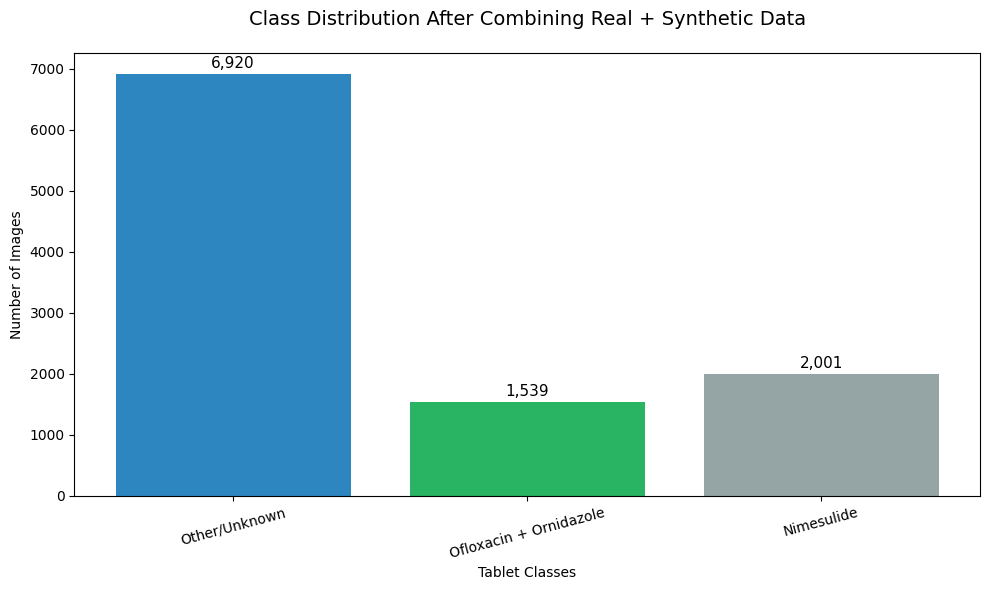


Balance Ratio (max/min): 4.5x
⚠️  Distribution is ACCEPTABLE.


In [4]:
# Cell 5: Dataset Distribution Summary

import numpy as np
from collections import Counter

# Combine real + synthetic labels for full picture
all_labels = []

# Real labels
all_labels.extend(labels)

# Synthetic labels
all_labels.extend(synthetic_labels)

# Count distribution
label_counts = Counter(all_labels)
label_names = {0: "Nimesulide", 1: "Ofloxacin + Ornidazole", 2: "Other/Unknown"}

print("="*60)
print("DATASET DISTRIBUTION SUMMARY (Real + Synthetic)")
print("="*60)
print(f"Total samples : {len(all_labels):,}\n")

for lbl, count in sorted(label_counts.items()):
    name = label_names.get(lbl, "Unknown")
    percentage = count / len(all_labels) * 100
    print(f"Class {lbl} : {name:25} → {count:6,} images  ({percentage:5.1f}%)")

print("-"*60)
print(f"Real images     : {len(labels):,}")
print(f"Synthetic images: {len(synthetic_labels):,}")
print("="*60)

# Visual bar plot
import matplotlib.pyplot as plt

labels_list = list(label_counts.keys())
counts = list(label_counts.values())
names = [label_names.get(l, "Unknown") for l in labels_list]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, counts, color=['#2E86C1', '#28B463', '#95A5A6'])
plt.title('Class Distribution After Combining Real + Synthetic Data', fontsize=14, pad=20)
plt.ylabel('Number of Images')
plt.xlabel('Tablet Classes')

# Add count labels on top of bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=11)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Check if distribution is balanced enough
min_count = min(label_counts.values())
max_count = max(label_counts.values())
ratio = max_count / min_count if min_count > 0 else float('inf')

print(f"\nBalance Ratio (max/min): {ratio:.1f}x")
if ratio < 3.0:
    print("✅ Distribution is GOOD and balanced enough for training.")
elif ratio < 6.0:
    print("⚠️  Distribution is ACCEPTABLE.")
else:
    print("❌ Distribution is still quite imbalanced. Consider generating more synthetic images for minority classes.")

In [5]:
# Cell 4: Augmentations + Combined Dataset  [FIXED]

train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=0.8),
    
    # Fixed GaussNoise - use 'var_limit' correctly or use 'std_range'
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),        # This is correct syntax
    
    # Alternative (if above still warns): use std_range
    # A.GaussNoise(std_range=(0.05, 0.15), p=0.4),
    
    A.MotionBlur(blur_limit=5, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class BlisterDataset(Dataset):
    def __init__(self, real_paths, real_labels, synth_imgs, synth_labels, transform=None, use_roi=True):
        self.real_paths = real_paths
        self.real_labels = real_labels
        self.synth_imgs = synth_imgs
        self.synth_labels = synth_labels
        self.transform = transform
        self.use_roi = use_roi

    def __len__(self):
        return len(self.real_paths) + len(self.synth_imgs)

    def apply_roi(self, img):
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 4))
        dilated = cv2.dilate(binary, kernel, iterations=2)
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            pad = 25
            roi = img[max(0, y-pad):y+h+pad, max(0, x-pad):x+w+pad]
            if roi.shape[0] > 60 and roi.shape[1] > 150:
                return cv2.resize(roi, (224, 224))
        return cv2.resize(img, (224, 224))

    def __getitem__(self, idx):
        if idx < len(self.real_paths):
            img = cv2.imread(self.real_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label = self.real_labels[idx]
        else:
            img = self.synth_imgs[idx - len(self.real_paths)]
            label = self.synth_labels[idx - len(self.real_paths)]

        if self.use_roi:
            img = self.apply_roi(img)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        return img, label


# Create combined dataset
full_dataset = BlisterDataset(image_paths, labels, synthetic_images, synthetic_labels, transform=train_transform)

train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=48, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=48, shuffle=False, num_workers=4, pin_memory=True)

print(f"Total training samples: {len(full_dataset)}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Total training samples: 10460
Train: 8891 | Val: 1569


/tmp/ipykernel_16/184741549.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.4),        # This is correct syntax


In [6]:
# Cell 5: Tiny Student Model + Knowledge Distillation Loss

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class TinyStudent(nn.Module):
    """Very lightweight CNN designed for Raspberry Pi 5"""
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),   # 112x112
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # 56x56

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # 28x28

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # 14x14

            # Block 4
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))                            # 1x1
        )
        
        self.classifier = nn.Linear(128, num_classes)
        
        # For KD we will also store teacher outputs
        self.num_classes = num_classes

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class TeacherModel(nn.Module):
    """Larger teacher model"""
    def __init__(self, num_classes=3):
        super().__init__()
        self.model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
    
    def forward(self, x):
        return self.model(x)


def kd_loss(student_logits, teacher_logits, labels, temperature=4.0, alpha=0.4):
    """Knowledge Distillation Loss"""
    # Soft targets from teacher
    soft_teacher = F.softmax(teacher_logits / temperature, dim=1)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    
    # KL Divergence loss
    kl_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (temperature ** 2)
    
    # Cross entropy with hard labels
    ce_loss = F.cross_entropy(student_logits, labels)
    
    # Combined loss
    loss = alpha * ce_loss + (1 - alpha) * kl_loss
    return loss


# Initialize models
teacher = TeacherModel(num_classes=3).to(device)
student = TinyStudent(num_classes=3).to(device)

print("Models initialized:")
print(f"   Teacher (ResNet18): ~11M params")
print(f"   Student (Tiny): ~0.18M params → Suitable for RPi 5")

Using device: cpu
Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


Models initialized:
   Teacher (ResNet18): ~11M params
   Student (Tiny): ~0.18M params → Suitable for RPi 5


In [7]:
# Cell 6: Training with Knowledge Distillation + Pruning

optimizer = torch.optim.AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

teacher.eval()   # Teacher is fixed during KD

print("Starting Knowledge Distillation Training...\n")

num_epochs = 25
best_val_acc = 0.0

for epoch in range(num_epochs):
    student.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Get teacher predictions (no gradient)
        with torch.no_grad():
            teacher_logits = teacher(images)
        
        # Student forward
        student_logits = student(images)
        
        # KD Loss
        loss = kd_loss(student_logits, teacher_logits, labels, temperature=4.0, alpha=0.4)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Accuracy
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    
    train_acc = 100. * correct / total
    avg_loss = total_loss / len(train_loader)
    
    print(f"Epoch [{epoch+1:2d}/{num_epochs}]  Loss: {avg_loss:.4f}  Train Acc: {train_acc:.2f}%")
    
    # Simple validation every 5 epochs
    if (epoch + 1) % 5 == 0:
        student.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = student(images)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        print(f"   Validation Accuracy: {val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), "best_student.pth")
            print(f"   ✓ New best model saved! Val Acc: {val_acc:.2f}%")

print(f"\nTraining completed! Best Validation Accuracy: {best_val_acc:.2f}%")

Starting Knowledge Distillation Training...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [ 1/25]  Loss: 0.3639  Train Acc: 70.30%
Epoch [ 2/25]  Loss: 0.3447  Train Acc: 74.38%
Epoch [ 3/25]  Loss: 0.3411  Train Acc: 75.82%
Epoch [ 4/25]  Loss: 0.3372  Train Acc: 75.90%
Epoch [ 5/25]  Loss: 0.3361  Train Acc: 76.48%
   Validation Accuracy: 79.03%
   ✓ New best model saved! Val Acc: 79.03%
Epoch [ 6/25]  Loss: 0.3337  Train Acc: 76.88%
Epoch [ 7/25]  Loss: 0.3316  Train Acc: 78.02%
Epoch [ 8/25]  Loss: 0.3317  Train Acc: 78.95%
Epoch [ 9/25]  Loss: 0.3281  Train Acc: 80.22%
Epoch [10/25]  Loss: 0.3245  Train Acc: 82.58%
   Validation Accuracy: 88.08%
   ✓ New best model saved! Val Acc: 88.08%
Epoch [11/25]  Loss: 0.3142  Train Acc: 87.67%
Epoch [12/25]  Loss: 0.3069  Train Acc: 90.48%
Epoch [13/25]  Loss: 0.3056  Train Acc: 91.15%
Epoch [14/25]  Loss: 0.3026  Train Acc: 92.69%
Epoch [15/25]  Loss: 0.2994  Train Acc: 93.93%
   Validation Accuracy: 95.86%
   ✓ New best model saved! Val Acc: 95.86%
Epoch [16/25]  Loss: 0.2973  Train Acc: 94.64%
Epoch [17/25]  Loss: 0.296

In [8]:
# Cell 7: Magnitude-based Pruning (Post-training)

def apply_pruning(model, threshold=0.025):
    """Prune small magnitude weights"""
    pruned_count = 0
    total_weights = 0
    
    for name, param in model.named_parameters():
        if 'weight' in name and param.requires_grad:
            mask = torch.abs(param.data) > threshold
            pruned = (~mask).sum().item()
            pruned_count += pruned
            total_weights += param.numel()
            param.data *= mask  # Zero out small weights
    
    prune_ratio = 100. * pruned_count / total_weights if total_weights > 0 else 0
    print(f"Pruning completed: {prune_ratio:.2f}% weights removed (threshold={threshold})")
    return model

print("Applying magnitude pruning...")
student = apply_pruning(student, threshold=0.025)

Applying magnitude pruning...
Pruning completed: 45.92% weights removed (threshold=0.025)


In [9]:
# Cell 8: Export Optimized Models (ONNX + TFLite)

import os
os.makedirs("/kaggle/working/models", exist_ok=True)

# 1. Export to ONNX
student.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "/kaggle/working/models/mediscan_student.onnx"
torch.onnx.export(
    student, 
    dummy_input, 
    onnx_path,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"ONNX model exported: {onnx_path}")

# 2. Dynamic INT8 Quantization
from onnxruntime.quantization import quantize_dynamic, QuantType

quantized_onnx_path = "/kaggle/working/models/mediscan_student_int8.onnx"
quantize_dynamic(
    onnx_path,
    quantized_onnx_path,
    weight_type=QuantType.QInt8
)

print(f"INT8 Quantized ONNX exported: {quantized_onnx_path}")

# 3. Convert to TFLite
import tensorflow as tf
from onnx_tf.backend import prepare
import onnx

print("Converting to TFLite...")

onnx_model = onnx.load(quantized_onnx_path)
tf_rep = prepare(onnx_model)
tf_rep.export_graph("/kaggle/working/models/mediscan_student_tf")

converter = tf.lite.TFLiteConverter.from_saved_model("/kaggle/working/models/mediscan_student_tf")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "/kaggle/working/models/mediscan_student.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"TFLite model exported: {tflite_path}")

# Show file sizes
print("\nModel Sizes:")
for f in ["mediscan_student.onnx", "mediscan_student_int8.onnx", "mediscan_student.tflite"]:
    size = os.path.getsize(f"/kaggle/working/models/{f}") / (1024*1024)
    print(f"   {f}: {size:.2f} MB")

ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
# Cell 9: Inference Benchmark + Summary

import onnxruntime as ort
import time

def benchmark_model(model_path, runs=100):
    sess = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
    input_name = sess.get_inputs()[0].name
    dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
    
    times = []
    for _ in range(runs):
        t0 = time.time()
        sess.run(None, {input_name: dummy})
        times.append(time.time() - t0)
    
    avg_ms = np.mean(times) * 1000
    fps = 1000 / avg_ms
    print(f"{model_path.split('/')[-1]:<25} → {avg_ms:.2f} ms/frame  |  {fps:.1f} FPS (CPU)")

print("Benchmarking models on CPU:\n")
benchmark_model("/kaggle/working/models/mediscan_student_int8.onnx", runs=200)
benchmark_model("/kaggle/working/models/mediscan_student.tflite", runs=200)

print("\n" + "="*60)
print("🎉 TRAINING & EXPORT COMPLETED!")
print("="*60)
print("Download these files from Kaggle Output:")
print("   • models/mediscan_student_int8.onnx")
print("   • models/mediscan_student.tflite")
print("\nNext: Copy them to your RPi and test with:")
print("   python mediscan_pipeline.py --demo --model models/mediscan_student_int8.onnx")